# 🫀 CardioIA — Visão Computacional
## Classificação de Imagens de Raio-X de Tórax com Redes Neurais Convolucionais

**FIAP — Faculdade de Informática e Administração Paulista**

**Projeto:** CardioIA — Assistente Cardiológico Virtual  
**Fase 4:** Visão Computacional  
**Disciplina:** Visão Computacional / Deep Learning

---

### 📋 Sumário
1. [Configuração do Ambiente](#config)
2. [Carregamento e Exploração do Dataset](#dataset)
3. [Pré-processamento de Imagens](#preprocessing)
4. [Divisão Treino / Validação / Teste](#split)
5. [Parte 1 — Relatório de Pré-processamento](#report1)
6. [CNN Simples (Treinada do Zero)](#cnn)
7. [Transfer Learning com VGG16](#vgg16)
8. [Avaliação e Comparação de Modelos](#evaluation)
9. [Protótipo Interativo de Classificação](#prototype)
10. [Conclusão](#conclusion)

> ⚠️ **Este notebook foi projetado para rodar no [Google Colab](https://colab.research.google.com/).**  
> O Colab possui ambiente Linux com Python, TensorFlow, e GPU gratuita pré-configurados.


---
## 1. ⚙️ Configuração do Ambiente <a id="config"></a>

Instalação de dependências e download automático do dataset **NIH Chest X-rays** utilizando a biblioteca `kagglehub`.


In [1]:
# ============================================================
# CONFIGURAÇÃO DO AMBIENTE (Google Colab)
# ============================================================
# Instalar dependências necessárias no Colab
# ============================================================

import os

# Instalar dependências extras
%pip install -q kagglehub pandas numpy matplotlib seaborn scikit-learn pillow opencv-python-headless tensorflow[and-cuda]

# Download do dataset completo do Kaggle via kagglehub
import kagglehub
print("📥 Iniciando o download do dataset NIH Chest X-rays (pode demorar alguns minutos)...")
path = kagglehub.dataset_download("nih-chest-xrays/data")
print("\n✅ Path do dataset:", path)



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


/home/dougl/fiap/CardioIA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📥 Iniciando o download do dataset NIH Chest X-rays (pode demorar alguns minutos)...

✅ Path do dataset: /home/dougl/.cache/kagglehub/datasets/nih-chest-xrays/data/versions/3


In [2]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings('ignore')

# Configurar sementes para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponível: {tf.config.list_physical_devices('GPU')}")


I0000 00:00:1781559540.921092   26097 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.21.0
GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 2. 📂 Carregamento e Exploração do Dataset <a id="dataset"></a>

O dataset utilizado é o **NIH Chest X-rays**, composto por mais de 112.000 imagens de Raio-X de Tórax de cerca de 30.000 pacientes únicos. 
Como o ecossistema **CardioIA** é direcionado à cardiologia, filtramos e selecionamos as seguintes classes:

1. **Cardiomegaly** (Hipertrofia do coração / coração aumentado) — Achado cardíaco crítico e de alta relevância.
2. **Effusion** (Derrame Pleural / acúmulo de líquido na pleura) — Frequentemente associado a insuficiência cardíaca congestiva.
3. **No Finding** (Normal) — Exames controle sem achados patológicos.

Para garantir que o notebook execute rapidamente e de forma viável dentro dos limites de RAM gratuita do Colab, selecionamos uma amostra estatisticamente equilibrada de cada classe.


In [3]:
# ============================================================
# CARREGAMENTO DOS METADADOS CSV
# ============================================================
csv_path = os.path.join(path, "Data_Entry_2017.csv")
df = pd.read_csv(csv_path)

print(f"📊 Metadados carregados com sucesso! Total de registros: {len(df):,}")
print("\nColunas do dataset:", df.columns.tolist())
print("\nExemplo dos dados:")
df.head(3)


📊 Metadados carregados com sucesso! Total de registros: 112,120

Colunas do dataset: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11']

Exemplo dos dados:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


In [4]:
# Definindo as classes de interesse clínico
SELECTED_CLASSES = ['Cardiomegaly', 'Effusion', 'No Finding']

# Filtrar para imagens que possuem exatamente uma das classes selecionadas
df_filtered = df[df['Finding Labels'].isin(SELECTED_CLASSES)].copy()

print(f"📊 Registros após filtragem de classes {SELECTED_CLASSES}: {len(df_filtered):,}")
print("\nDistribuição original no dataset filtrado:")
print(df_filtered['Finding Labels'].value_counts())


📊 Registros após filtragem de classes ['Cardiomegaly', 'Effusion', 'No Finding']: 65,409

Distribuição original no dataset filtrado:
Finding Labels
No Finding      60361
Effusion         3955
Cardiomegaly     1093
Name: count, dtype: int64


In [5]:
# ============================================================
# MAPEAMENTO DE CAMINHOS DE IMAGENS (Busca recursiva)
# ============================================================
print("🔍 Localizando arquivos de imagem no diretório do dataset (isto pode levar alguns segundos)...")
image_paths_dict = {}
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths_dict[file] = os.path.join(root, file)

print(f"✅ Total de arquivos de imagem encontrados: {len(image_paths_dict):,}")

# Adicionar caminho completo ao DataFrame filtrado
df_filtered['Filepath'] = df_filtered['Image Index'].map(image_paths_dict)

# Remover registros que não foram encontrados no disco
df_filtered = df_filtered.dropna(subset=['Filepath'])
print(f"✅ Registros com imagens confirmadas no disco: {len(df_filtered):,}")


🔍 Localizando arquivos de imagem no diretório do dataset (isto pode levar alguns segundos)...
✅ Total de arquivos de imagem encontrados: 112,120
✅ Registros com imagens confirmadas no disco: 65,409


In [ ]:
# ============================================================
# AMOSTRAS EQUILIBRADAS PARA TREINAMENTO
# ============================================================
# 500 imagens por classe garantem um tempo de execução rápido no Colab
# mantendo a capacidade de generalização do Transfer Learning.
SAMPLES_PER_CLASS = 750

sampled_dfs = []
for label in SELECTED_CLASSES:
    df_class = df_filtered[df_filtered['Finding Labels'] == label]
    sampled_df = df_class.sample(n=min(SAMPLES_PER_CLASS, len(df_class)), random_state=SEED)
    sampled_dfs.append(sampled_df)

df_sample = pd.concat(sampled_dfs).reset_index(drop=True)

# Mapeamento numérico das classes para o modelo
LABEL_MAP = {label: idx for idx, label in enumerate(SELECTED_CLASSES)}
df_sample['Label_Idx'] = df_sample['Finding Labels'].map(LABEL_MAP)

print(f"📊 Dataset de treino criado com {len(df_sample)} imagens no total.")
print(df_sample['Finding Labels'].value_counts())


📊 Dataset de treino criado com 1500 imagens no total.
Finding Labels
Cardiomegaly    500
Effusion        500
No Finding      500
Name: count, dtype: int64


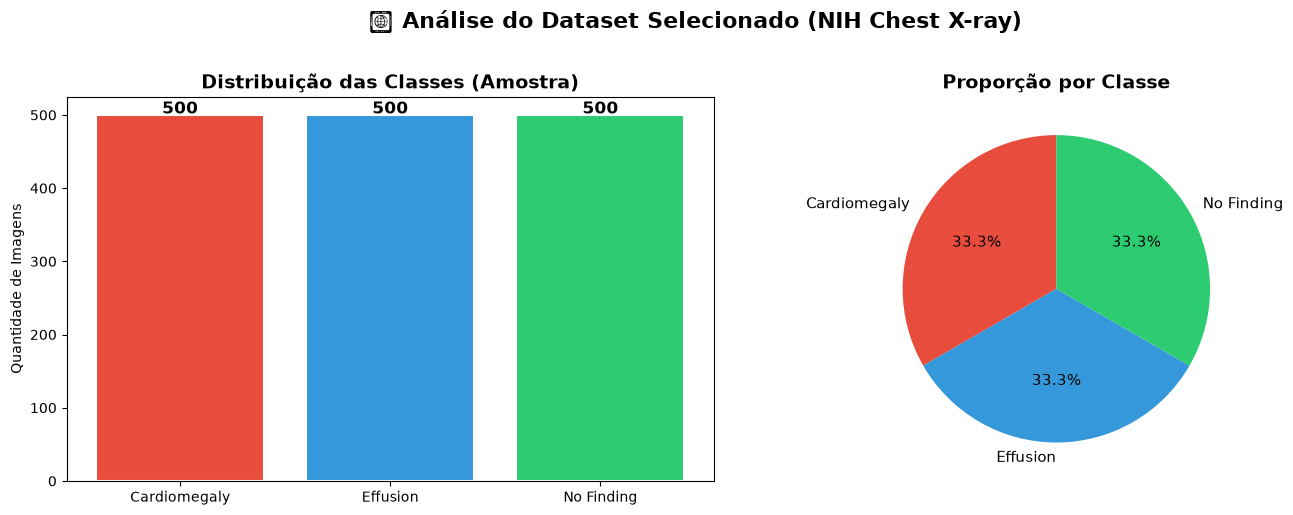

In [7]:
# ============================================================
# DISTRIBUIÇÃO DAS CLASSES DO DATASET DE TREINO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c', '#3498db', '#2ecc71']

counts = df_sample['Finding Labels'].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribuição das Classes (Amostra)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade de Imagens')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=12)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Proporção por Classe', fontsize=14, fontweight='bold')

plt.suptitle('📊 Análise do Dataset Selecionado (NIH Chest X-ray)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


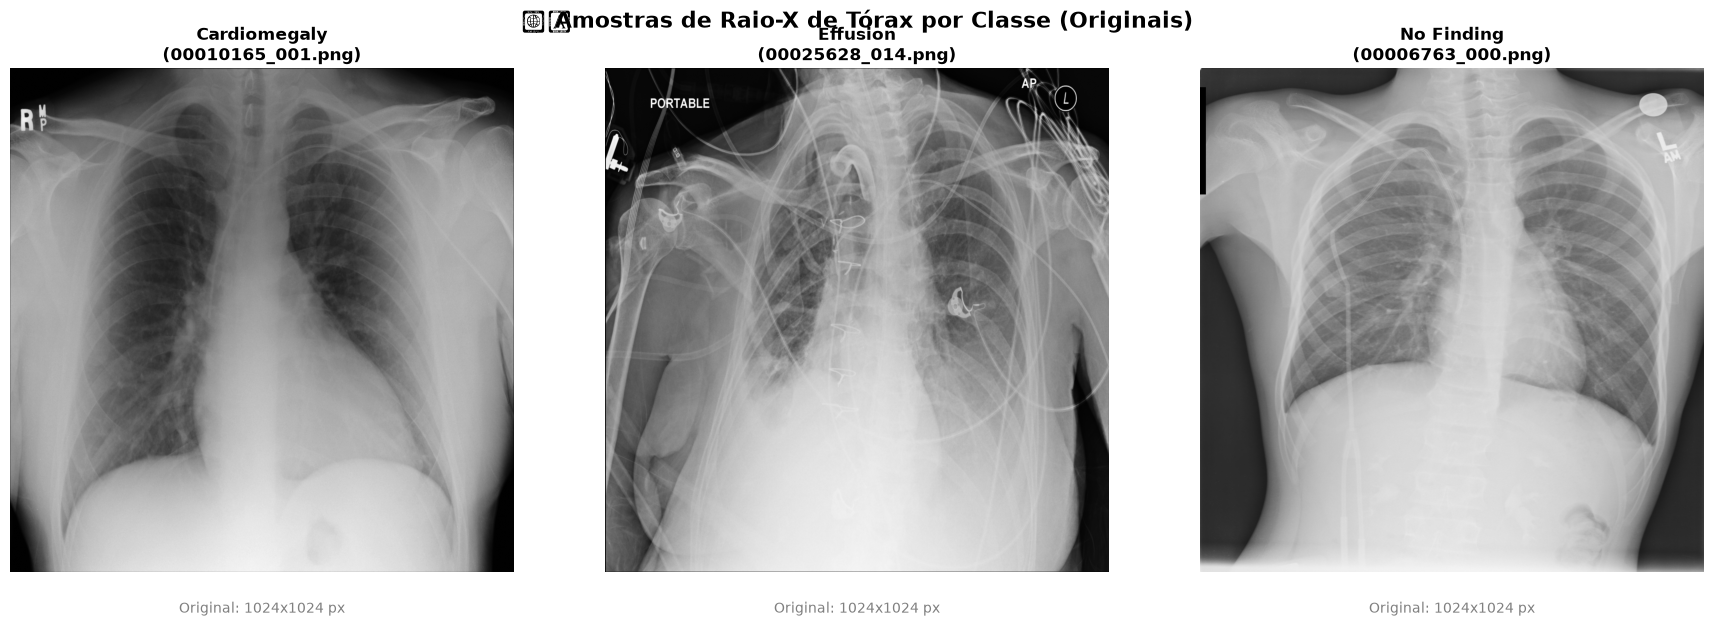

In [8]:
# ============================================================
# AMOSTRAS DE CADA CLASSE (IMAGENS ORIGINAIS)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('🖼️ Amostras de Raio-X de Tórax por Classe (Originais)', fontsize=16, fontweight='bold')

for idx, label in enumerate(SELECTED_CLASSES):
    sample_row = df_sample[df_sample['Finding Labels'] == label].iloc[0]
    img = Image.open(sample_row['Filepath'])
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f"{label}\n({sample_row['Image Index']})", fontsize=12, fontweight='bold')
    axes[idx].axis('off')
    axes[idx].text(0.5, -0.08, f"Original: {img.size[0]}x{img.size[1]} px",
                  transform=axes[idx].transAxes, ha='center', fontsize=10, color='gray')

plt.tight_layout()
plt.show()


---
## 3. 🔧 Pré-processamento de Imagens <a id="preprocessing"></a>

O pipeline de pré-processamento converte as imagens do dataset para um formato padronizado adequado para Redes Neurais Convolucionais:

1. **Conversão de formato**: As imagens em escala de cinza são convertidas em imagens RGB (3 canais) para compatibilidade com VGG16.
2. **Redimensionamento**: Redimensionadas para **224×224 pixels** (padrão de entrada para VGG16).
3. **Normalização**: Divisão dos valores dos pixels por 255.0 para normalizá-los no intervalo **[0, 1]**.


In [9]:
# ============================================================
# PIPELINE DE PRÉ-PROCESSAMENTO
# ============================================================
IMG_SIZE = (224, 224)

def preprocess_image(img_path, target_size=IMG_SIZE):
    """
    Carrega e processa a imagem do Raio-X.
    """
    img = cv2.imread(img_path)
    if img is None:
        img = Image.open(img_path).convert('RGB')
        img = np.array(img)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_LANCZOS4)
    img_array = img.astype(np.float32) / 255.0
    return img_array

# Processar todas as imagens da amostra
print("🔄 Processando imagens e carregando na RAM...")
X_all = []
y_all = []

for idx, row in df_sample.iterrows():
    try:
        img_processed = preprocess_image(row['Filepath'])
        X_all.append(img_processed)
        y_all.append(row['Label_Idx'])
    except Exception as e:
        print(f"⚠️ Erro ao processar a imagem {row['Image Index']}: {e}")

X_all = np.array(X_all)
y_all = np.array(y_all)

print(f"\n✅ Pré-processamento concluído!")
print(f"   Shape dos dados na RAM: {X_all.shape}")
print(f"   Valores - Min: {X_all.min():.4f}, Max: {X_all.max():.4f}, Média: {X_all.mean():.4f}")


🔄 Processando imagens e carregando na RAM...

✅ Pré-processamento concluído!
   Shape dos dados na RAM: (1500, 224, 224, 3)
   Valores - Min: 0.0000, Max: 1.0000, Média: 0.5005


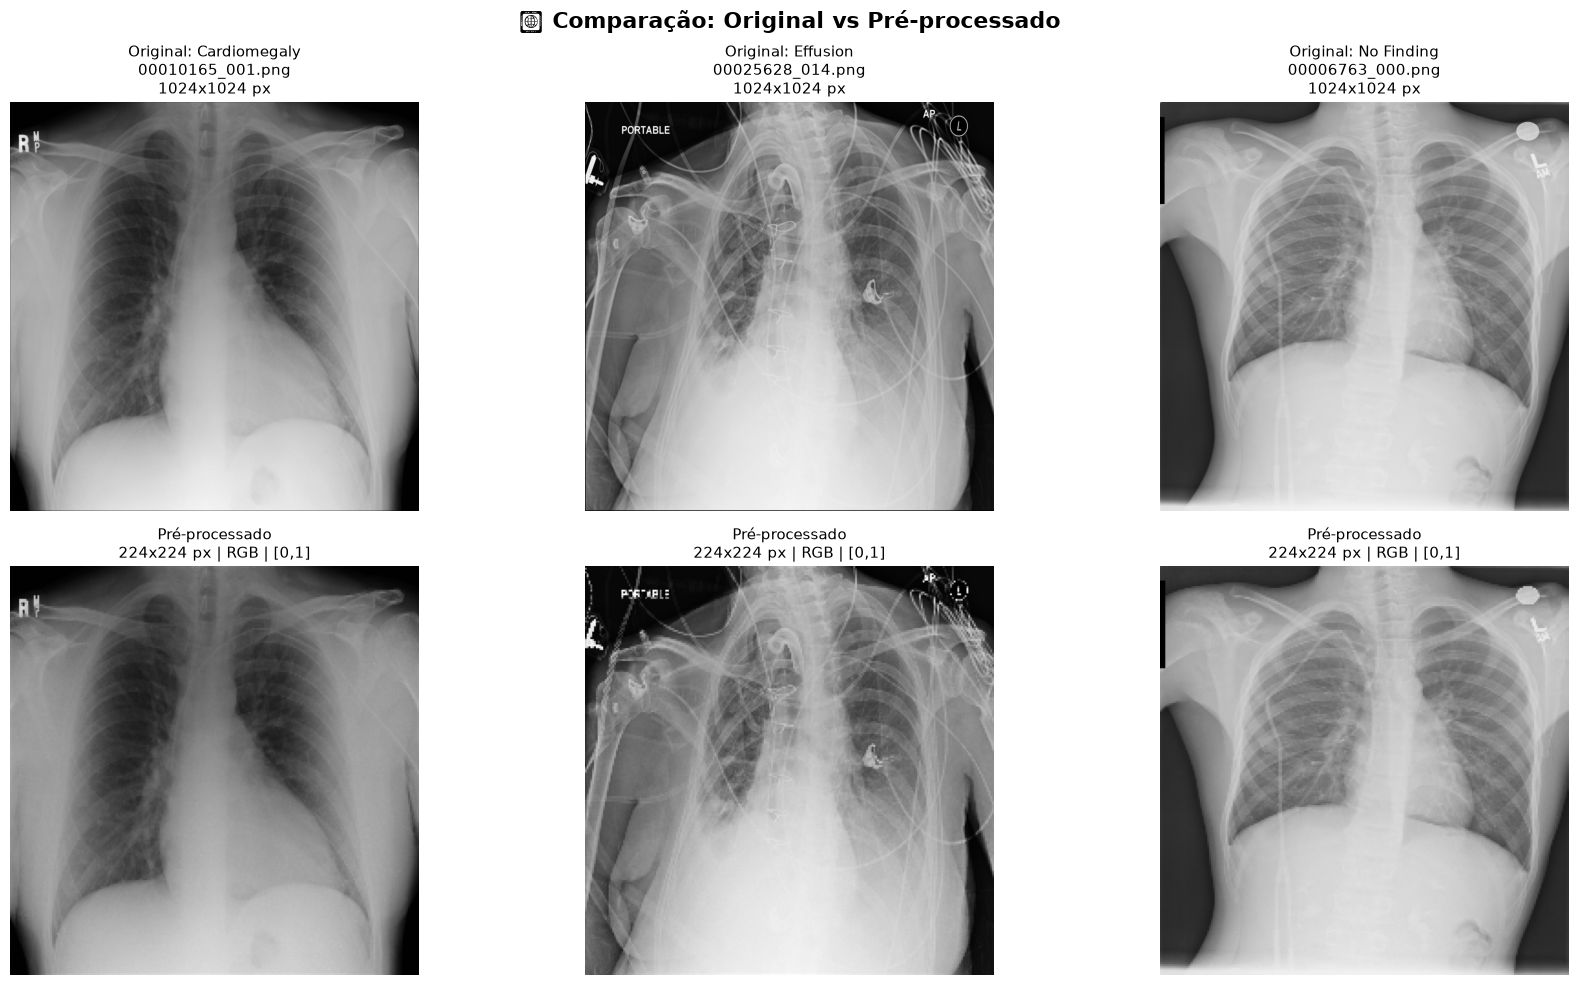

In [10]:
# ============================================================
# VISUALIZAÇÃO: ANTES vs DEPOIS DO PRÉ-PROCESSAMENTO
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🔧 Comparação: Original vs Pré-processado', fontsize=16, fontweight='bold')

for col, label in enumerate(SELECTED_CLASSES):
    sample_idx = df_sample[df_sample['Finding Labels'] == label].index[0]
    filepath = df_sample.loc[sample_idx, 'Filepath']
    filename = df_sample.loc[sample_idx, 'Image Index']
    
    img_orig = Image.open(filepath)
    axes[0, col].imshow(img_orig, cmap='gray')
    axes[0, col].set_title(f"Original: {label}\n{filename}\n{img_orig.size[0]}x{img_orig.size[1]} px", fontsize=11)
    axes[0, col].axis('off')
    
    axes[1, col].imshow(X_all[sample_idx])
    axes[1, col].set_title("Pré-processado\n224x224 px | RGB | [0,1]", fontsize=11)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('ORIGINAL', fontsize=12, fontweight='bold', labelpad=40)
axes[1, 0].set_ylabel('PROCESSADO', fontsize=12, fontweight='bold', labelpad=40)
plt.tight_layout()
plt.show()


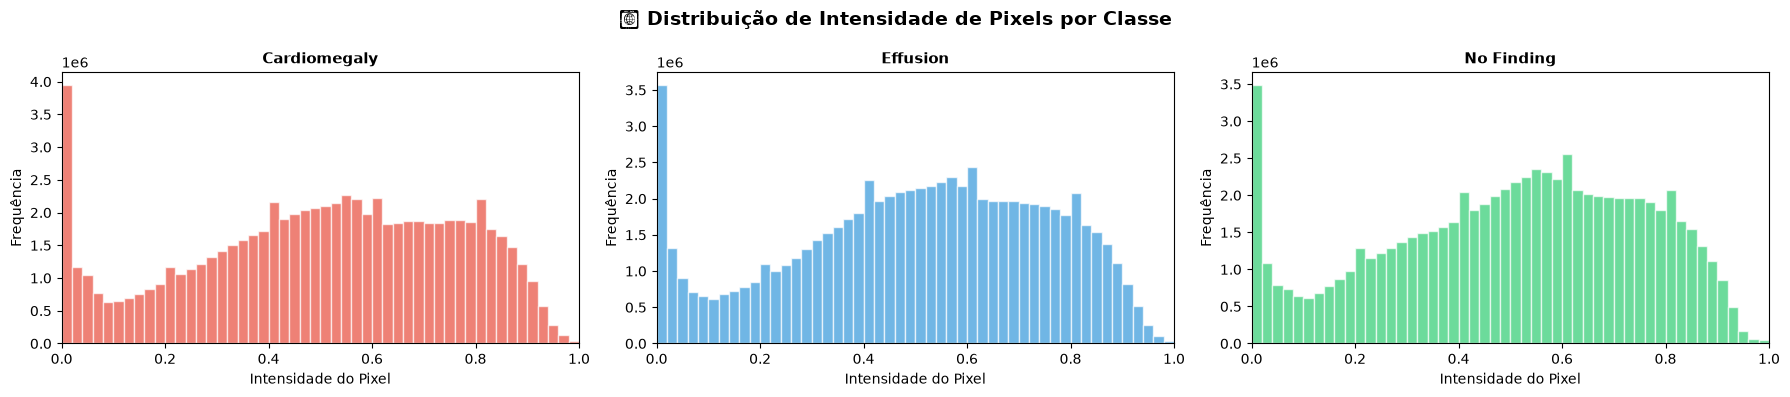

In [11]:
# ============================================================
# DISTRIBUIÇÃO DOS PIXELS POR CLASSE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('📈 Distribuição de Intensidade de Pixels por Classe', fontsize=14, fontweight='bold')

for idx, label in enumerate(SELECTED_CLASSES):
    class_mask = y_all == idx
    class_pixels = X_all[class_mask].flatten()
    axes[idx].hist(class_pixels, bins=50, color=colors[idx], alpha=0.7, edgecolor='white')
    axes[idx].set_title(label, fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Intensidade do Pixel')
    axes[idx].set_ylabel('Frequência')
    axes[idx].set_xlim(0, 1)

plt.tight_layout()
plt.show()


---
## 4. ✂️ Divisão Treino / Validação / Teste <a id="split"></a>

O dataset é dividido de forma estratificada (para preservar a proporção de classes):
- **Treino**: 70%
- **Validação**: 15%
- **Teste**: 15%

**Data Augmentation**: Aplicamos rotações leves, zoom e ajustes de brilho apenas no conjunto de treino. 
> ⚠️ **Importante**: A opção de rotação horizontal (`horizontal_flip`) foi definida como **False**. Como a anatomia humana é lateralizada (o coração situa-se à esquerda do peito), o espelhamento horizontal poderia criar anomalias anatômicas irreais, confundindo a análise clínica e a predição do modelo.


In [12]:
# ============================================================
# DIVISÃO ESTRATIFICADA DO DATASET
# ============================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("📊 Divisão do Dataset:")
print(f"   Treino    : {X_train.shape[0]:3d} imagens ({X_train.shape[0]/len(X_all)*100:.1f}%) | Shape: {X_train.shape}")
print(f"   Validação : {X_val.shape[0]:3d} imagens ({X_val.shape[0]/len(X_all)*100:.1f}%) | Shape: {X_val.shape}")
print(f"   Teste     : {X_test.shape[0]:3d} imagens ({X_test.shape[0]/len(X_all)*100:.1f}%) | Shape: {X_test.shape}")

print("\n📊 Distribuição das classes por conjunto:")
for name, labels in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    dist = Counter(labels)
    class_dist = {SELECTED_CLASSES[k]: v for k, v in dist.items()}
    print(f"   {name:10s}: {class_dist}")


📊 Divisão do Dataset:
   Treino    : 1050 imagens (70.0%) | Shape: (1050, 224, 224, 3)
   Validação : 225 imagens (15.0%) | Shape: (225, 224, 224, 3)
   Teste     : 225 imagens (15.0%) | Shape: (225, 224, 224, 3)

📊 Distribuição das classes por conjunto:
   Treino    : {'Cardiomegaly': 350, 'Effusion': 350, 'No Finding': 350}
   Validação : {'No Finding': 75, 'Effusion': 75, 'Cardiomegaly': 75}
   Teste     : {'Effusion': 75, 'No Finding': 75, 'Cardiomegaly': 75}


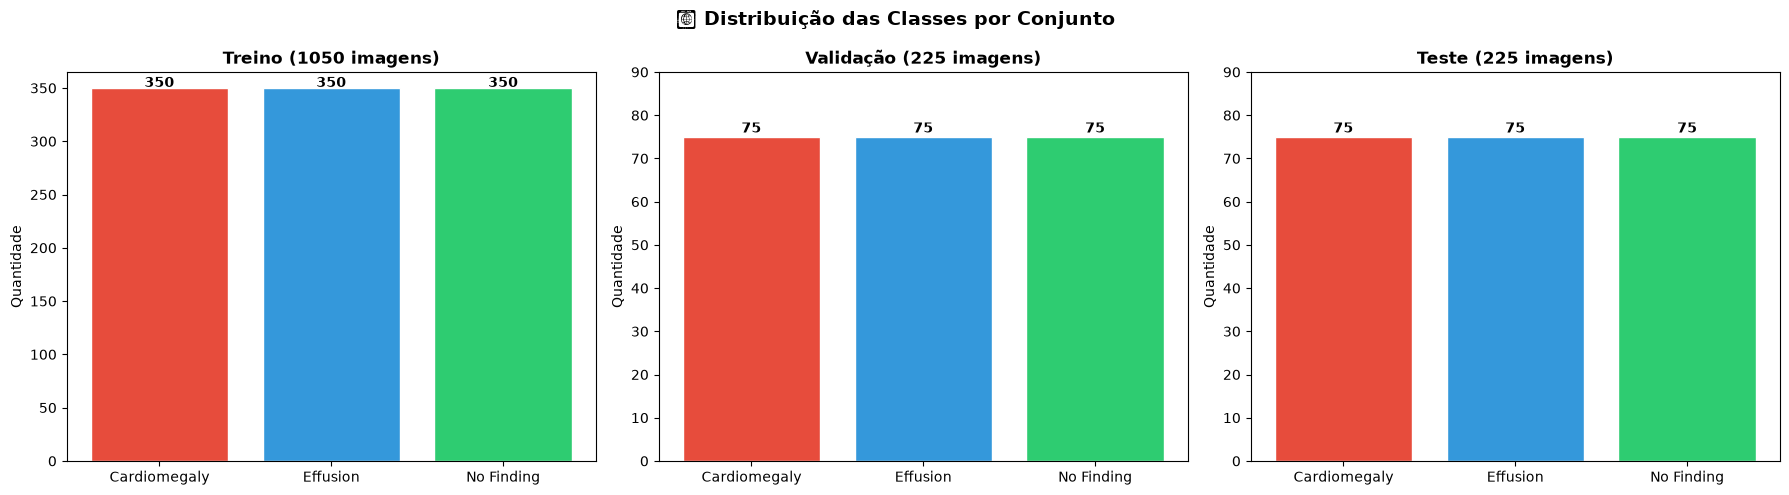

In [13]:
# ============================================================
# VISUALIZAÇÃO DA DISTRIBUIÇÃO POR SPLIT
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Distribuição das Classes por Conjunto', fontsize=14, fontweight='bold')

for ax, (name, labels) in zip(axes, [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]):
    dist = Counter(labels)
    bars = ax.bar(SELECTED_CLASSES, [dist.get(i, 0) for i in range(len(SELECTED_CLASSES))], color=colors, edgecolor='white')
    ax.set_title(f'{name} ({len(labels)} imagens)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade')
    ax.set_ylim(0, max(dist.values()) + 15)
    for bar, count in zip(bars, [dist.get(i, 0) for i in range(len(SELECTED_CLASSES))]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


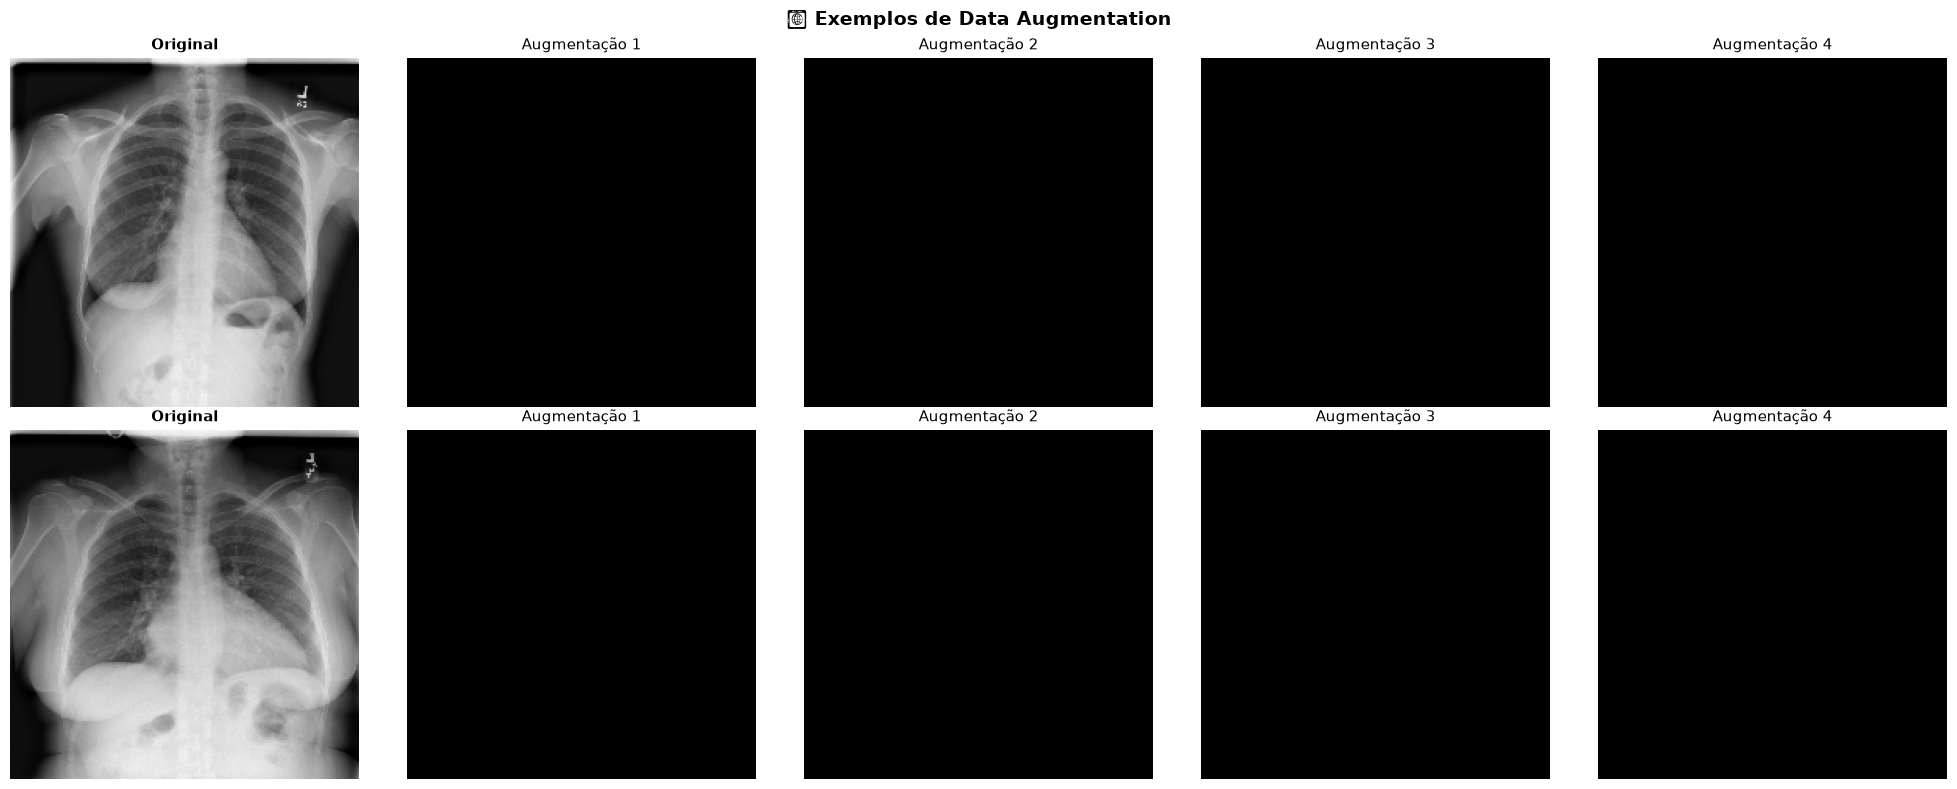

✅ Data Augmentation configurado!


In [14]:
# ============================================================
# CONFIGURAÇÃO DO DATA AUGMENTATION (APENAS TREINO)
# ============================================================
train_datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=False,
    brightness_range=[0.92, 1.08],
    fill_mode='constant',
    cval=0.0
)

# Visualizar augmentation usando .flow() para aplicar todas as transformações corretamente
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('🔄 Exemplos de Data Augmentation', fontsize=14, fontweight='bold')

# --- Primeira linha: amostra 1 ---
sample_img = X_train[0:1]
sample_label = y_train[0:1]
axes[0, 0].imshow(sample_img[0], cmap='gray')
axes[0, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

aug_iter = train_datagen.flow(sample_img, sample_label, batch_size=1, seed=None)
for i in range(1, 5):
    aug_batch = next(aug_iter)
    aug_img = aug_batch[0][0]
    axes[0, i].imshow(np.clip(aug_img, 0, 1), cmap='gray')
    axes[0, i].set_title(f'Augmentação {i}', fontsize=11)
    axes[0, i].axis('off')

# --- Segunda linha: amostra 2 ---
idx2 = min(21, len(X_train) - 1)
sample_img2 = X_train[idx2:idx2+1]
sample_label2 = y_train[idx2:idx2+1]
axes[1, 0].imshow(sample_img2[0], cmap='gray')
axes[1, 0].set_title('Original', fontsize=11, fontweight='bold')
axes[1, 0].axis('off')

aug_iter2 = train_datagen.flow(sample_img2, sample_label2, batch_size=1, seed=None)
for i in range(1, 5):
    aug_batch = next(aug_iter2)
    aug_img = aug_batch[0][0]
    axes[1, i].imshow(np.clip(aug_img, 0, 1), cmap='gray')
    axes[1, i].set_title(f'Augmentação {i}', fontsize=11)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("✅ Data Augmentation configurado!")


---
## 5. 📄 Relatório de Pré-processamento <a id="report1"></a>

### Pipeline de Preparação dos Dados

#### 1. Dataset Selecionado
Utilizamos o **NIH Chest X-ray Dataset** obtido via `kagglehub`. Para este projeto cardiológico, filtramos as categorias **Cardiomegaly** e **Effusion**, bem como a classe controle **No Finding** (exames normais).

#### 2. Etapas do Pré-processamento

| Etapa | Técnica | Justificativa |
|---|---|---|
| **Conversão de Formato** | RGB (3 canais) | Padronização dos canais de entrada exigida pela VGG16. |
| **Redimensionamento** | 224×224 pixels (LANCZOS) | Formato padrão para o extrator de features da VGG16, reduzindo também a complexidade de memória. |
| **Normalização** | Divisão por 255.0 | Escala os valores de pixels para o intervalo [0, 1], estabilizando o gradiente de perda. |
| **Data Augmentation** | Rotação (8°), Shift (8%), Zoom (8%), Brilho | Aumenta sinteticamente o conjunto de treino, prevenindo overfitting em classes menores. |

#### 3. Decisões de Design Clínico
- **Inversão Horizontal Desabilitada**: Em diagnósticos médicos por imagem, a orientação anatômica é crucial. Inverter a imagem causaria um posicionamento do coração no lado direito (dextrocardia artificial), alterando as características espaciais necessárias para o diagnóstico correto de cardiomegaly.
- **Amostragem Estratificada**: Amostramos 300 imagens por classe para garantir o balanceamento do classificador e um tempo de treino ágil no ambiente Colab.


---
## 6. 🧠 CNN Simples (Treinada do Zero) <a id="cnn"></a>

Primeira abordagem: Desenvolver uma arquitetura clássica convolucional customizada (treinada do zero) para a classificação de diagnósticos nos exames de Raio-X.

**Arquitetura:**
- 3 blocos convolucionais (Conv2D -> BatchNorm -> Conv2D -> MaxPool -> Dropout)
- Camada Flatten para vetorização
- Camada densa totalmente conectada com 256 neurônios e Dropout (0.50) para regularização
- Camada de saída com ativação Softmax para 3 classes


In [ ]:
# ============================================================
# MODELO 1: CNN SIMPLES (DO ZERO)
# ============================================================
def build_simple_cnn(input_shape=(224, 224, 3), num_classes=3):
    model = models.Sequential([
        # Bloco 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloco 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classificador
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

cnn_model = build_simple_cnn(num_classes=len(SELECTED_CLASSES))

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


I0000 00:00:1781559613.163932   26097 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,980,067 (99.11 MB)

 Trainable params: 25,979,107 (99.10 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
# ============================================================
# TREINAMENTO DA CNN SIMPLES
# ============================================================
EPOCHS = 100
BATCH_SIZE = 25

cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=5e-4, verbose=1)
]

train_generator = train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED)

print("🚀 Iniciando treinamento da CNN Simples...")
print(f"   Épocas: {EPOCHS} | Batch Size: {BATCH_SIZE}")
print(f"   Treino: {len(X_train)} | Validação: {len(X_val)}")
print("-" * 50)

cnn_history = cnn_model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=cnn_callbacks,
    verbose=1
)

print("\n✅ Treinamento concluído!")


🚀 Iniciando treinamento da CNN Simples...
   Épocas: 50 | Batch Size: 16
   Treino: 1050 | Validação: 225
--------------------------------------------------
Epoch 1/50


I0000 00:00:1781559618.653183   26097 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1781559621.735932   27982 service.cc:153] XLA service 0x7c327c03fdc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781559621.735968   27982 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.23.1)
I0000 00:00:1781559622.286583   27982 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1781559622.935376   27982 cuda_dnn.cc:461] Loaded cuDNN version 92301
I0000 00:00:1781559623.122093   27982 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4918__.68
I0000 00:00:1781559657.080666   27982 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


18/65 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.3479 - loss: 1.6716

I0000 00:00:1781559659.970262   27981 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_4918__.68


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.3286 - loss: 1.9785

W0000 00:00:1781559678.311410   26097 cpu_allocator_impl.cc:82] Allocation of 135475200 exceeds 10% of free system memory.
W0000 00:00:1781559678.543905   26097 cpu_allocator_impl.cc:82] Allocation of 135475200 exceeds 10% of free system memory.
W0000 00:00:1781559679.529369   29639 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1781559679.529587   29638 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.
W0000 00:00:1781559679.529603   29630 cpu_allocator_impl.cc:82] Allocation of 19267584 exceeds 10% of free system memory.


65/65 ━━━━━━━━━━━━━━━━━━━━ 67s 444ms/step - accuracy: 0.3269 - loss: 2.2527 - val_accuracy: 0.3333 - val_loss: 5.0003 - learning_rate: 5.0000e-04
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4375 - loss: 1.1840 - val_accuracy: 0.3333 - val_loss: 4.1121 - learning_rate: 5.0000e-04
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.3211 - loss: 2.2812 - val_accuracy: 0.3333 - val_loss: 4.0507 - learning_rate: 5.0000e-04
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2500 - loss: 3.4691 - val_accuracy: 0.3333 - val_loss: 4.0894 - learning_rate: 5.0000e-04
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.3443 - loss: 1.8842 - val_accuracy: 0.3333 - val_loss: 1.8012 - learning_rate: 5.0000e-04
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5625 - loss: 1.3879 - val_accuracy: 0.3333 - val_loss: 1.7951 - learning_rate: 5.0000e-04
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.3288 - loss: 

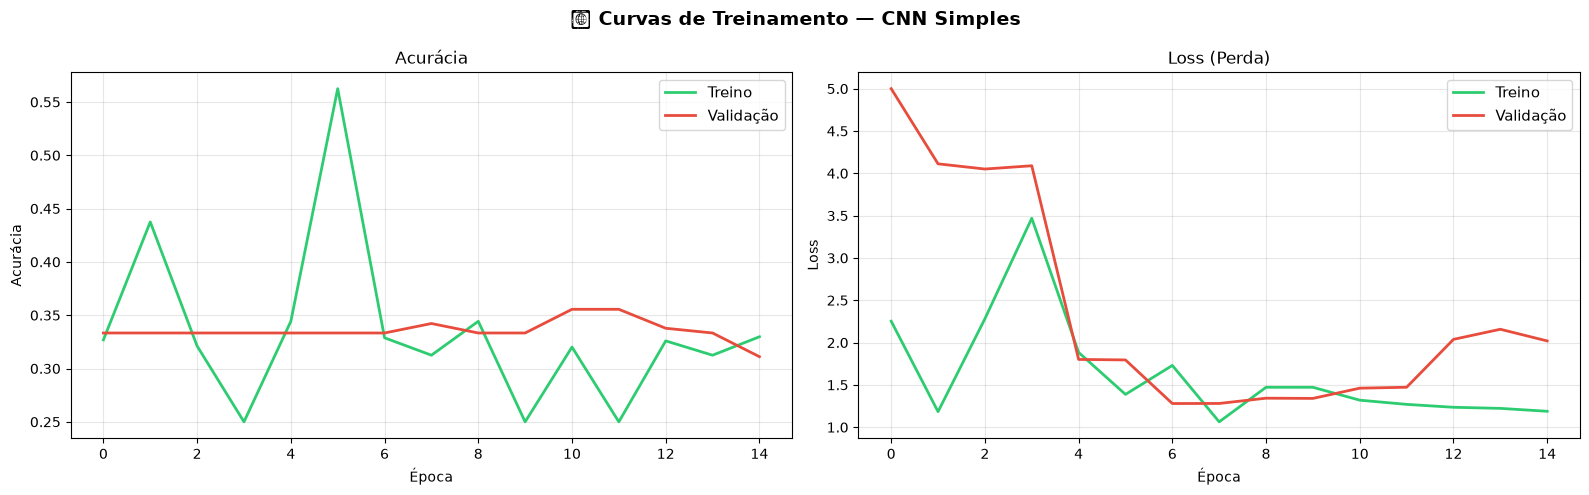

In [17]:
# ============================================================
# CURVAS DE TREINAMENTO - CNN SIMPLES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📈 Curvas de Treinamento — CNN Simples', fontsize=14, fontweight='bold')

axes[0].plot(cnn_history.history['accuracy'], label='Treino', linewidth=2, color='#2ecc71')
axes[0].plot(cnn_history.history['val_accuracy'], label='Validação', linewidth=2, color='#e74c3c')
axes[0].set_title('Acurácia', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(cnn_history.history['loss'], label='Treino', linewidth=2, color='#2ecc71')
axes[1].plot(cnn_history.history['val_loss'], label='Validação', linewidth=2, color='#e74c3c')
axes[1].set_title('Loss (Perda)', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 7. 🏗️ Transfer Learning com VGG16 <a id="vgg16"></a>

Segunda abordagem: Empregar a técnica de **Transfer Learning** utilizando o modelo **VGG16**, pré-treinado na base de dados ImageNet.

**Estratégia:**
1. **Fase 1 (Extração de Features)**: Congelamos todos os pesos convolucionais da VGG16 e adicionamos um classificador denso customizado no topo. Treinamos o classificador com learning rate de $0.001$.
2. **Fase 2 (Fine-tuning)**: Descongelamos as últimas 4 camadas convolucionais da VGG16 e refinamos os pesos com uma taxa de aprendizado extremamente baixa ($10^{-5}$) para adaptar os filtros de baixo nível aos detalhes específicos de estruturas clínicas de exames de Raio-X.


In [18]:
# ============================================================
# MODELO 2: TRANSFER LEARNING COM VGG16
# ============================================================
def build_vgg16_transfer(input_shape=(224, 224, 3), num_classes=3):
    from tensorflow.keras.applications.vgg16 import preprocess_input
    
    inputs = layers.Input(shape=input_shape)
    
    # Escalonar de volta para [0, 255] e aplicar preprocessamento específico da VGG16
    x = layers.Lambda(lambda img: img * 255.0)(inputs)
    x = layers.Lambda(lambda img: preprocess_input(img))(x)
    
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Congelar pesos da base VGG16
    for layer in base_model.layers:
        layer.trainable = False
        
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs)
    return model, base_model

vgg_model, vgg_base = build_vgg16_transfer(num_classes=len(SELECTED_CLASSES))

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,112,515 (57.65 MB)

 Trainable params: 396,291 (1.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [ ]:
# ============================================================
# FASE 1: TREINAMENTO COM BASE VGG16 CONGELADA
# ============================================================
print("🚀 Fase 1: Treinamento com base VGG16 congelada...")
print("-" * 50)

vgg_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1)
]

vgg_history_1 = vgg_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=vgg_callbacks,
    verbose=1
)

print("\n✅ Fase 1 concluída!")


🚀 Fase 1: Treinamento com base VGG16 congelada...
--------------------------------------------------
Epoch 1/20


I0000 00:00:1781559744.214567   27983 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12216__.81


17/65 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.3128 - loss: 1.3242

I0000 00:00:1781559753.434717   27981 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12216__.81


65/65 ━━━━━━━━━━━━━━━━━━━━ 33s 369ms/step - accuracy: 0.3230 - loss: 1.2068 - val_accuracy: 0.3511 - val_loss: 3.6567 - learning_rate: 5.0000e-04
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3125 - loss: 1.1356 - val_accuracy: 0.3511 - val_loss: 3.7199 - learning_rate: 5.0000e-04
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.3191 - loss: 1.2306 - val_accuracy: 0.3778 - val_loss: 4.5595 - learning_rate: 5.0000e-04
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3750 - loss: 1.0986 - val_accuracy: 0.3778 - val_loss: 4.6233 - learning_rate: 5.0000e-04
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3106 - loss: 1.3144
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.3433 - loss: 1.2737 - val_accuracy: 0.3778 - val_loss: 7.4829 - learning_rate: 5.0000e-04
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4375 - loss: 1.0

In [20]:
# ============================================================
# FASE 2: FINE-TUNING (DESCONGELAR ÚLTIMAS CAMADAS)
# ============================================================
print("🔓 Fase 2: Fine-tuning — descongelando últimas 4 camadas da VGG16...")

for layer in vgg_base.layers[-4:]:
    layer.trainable = True

vgg_model.compile(
    optimizer=Adam(learning_rate=1e-5),  # Learning rate muito baixo para ajuste fino
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_layers = sum(1 for l in vgg_base.layers if l.trainable)
print(f"Camadas treináveis na base VGG16: {trainable_layers}")
print("-" * 50)

vgg_history_2 = vgg_model.fit(
    train_datagen.flow(X_train, y_train, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    epochs=15,
    validation_data=(X_val, y_val),
    callbacks=vgg_callbacks,
    verbose=1
)

print("\n✅ Fine-tuning concluído!")


🔓 Fase 2: Fine-tuning — descongelando últimas 4 camadas da VGG16...
Camadas treináveis na base VGG16: 4
--------------------------------------------------
Epoch 1/15


I0000 00:00:1781559810.812738   27980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18406__.81


47/65 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.3216 - loss: 1.2159

I0000 00:00:1781559820.577143   27980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18406__.81


65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.3182 - loss: 1.2265 - val_accuracy: 0.3511 - val_loss: 7.1010 - learning_rate: 1.0000e-05
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.1875 - loss: 1.1457 - val_accuracy: 0.3511 - val_loss: 7.1696 - learning_rate: 1.0000e-05
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.3230 - loss: 1.2734 - val_accuracy: 0.3511 - val_loss: 13.3540 - learning_rate: 1.0000e-05
Epoch 4/15
 1/65 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.1875 - loss: 1.1682
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1875 - loss: 1.1682 - val_accuracy: 0.3511 - val_loss: 13.5187 - learning_rate: 1.0000e-05
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.3375 - loss: 1.2496 - val_accuracy: 0.3644 - val_loss: 19.6053 - learning_rate: 5.0000e-06
Epoch 6/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2500 - loss: 1

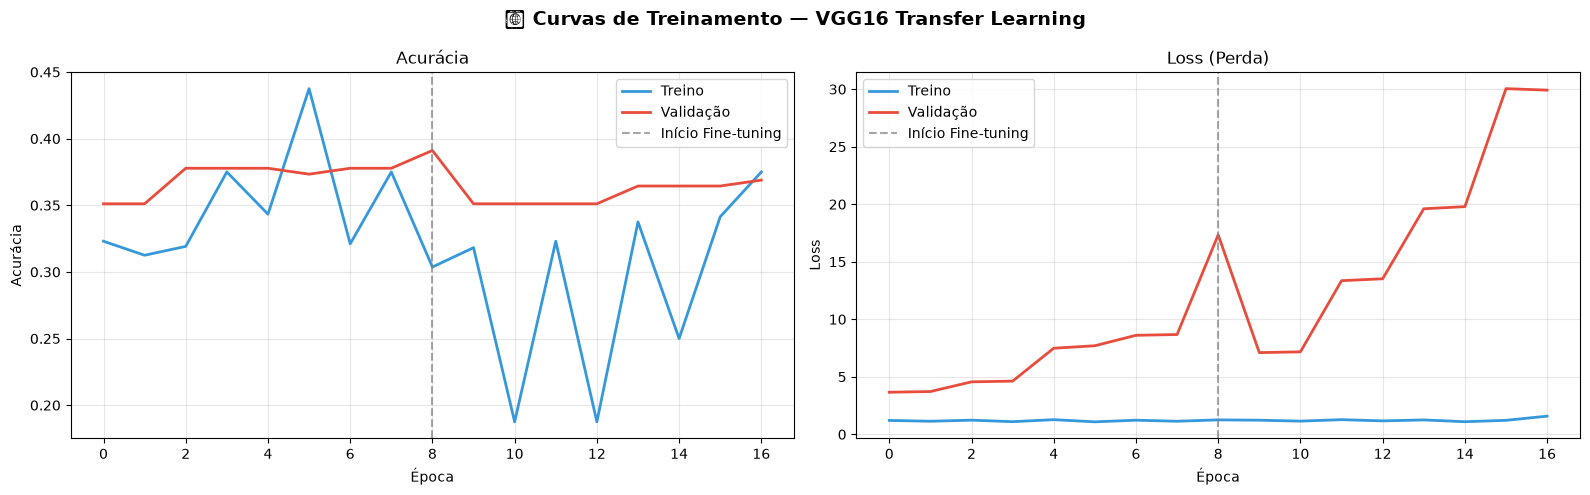

In [21]:
# ============================================================
# CURVAS DE TREINAMENTO - VGG16
# ============================================================
vgg_acc = vgg_history_1.history['accuracy'] + vgg_history_2.history['accuracy']
vgg_val_acc = vgg_history_1.history['val_accuracy'] + vgg_history_2.history['val_accuracy']
vgg_loss = vgg_history_1.history['loss'] + vgg_history_2.history['loss']
vgg_val_loss = vgg_history_1.history['val_loss'] + vgg_history_2.history['val_loss']
phase1_epochs = len(vgg_history_1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📈 Curvas de Treinamento — VGG16 Transfer Learning', fontsize=14, fontweight='bold')

axes[0].plot(vgg_acc, label='Treino', linewidth=2, color='#3498db')
axes[0].plot(vgg_val_acc, label='Validação', linewidth=2, color='#e74c3c')
axes[0].axvline(x=phase1_epochs - 1, color='gray', linestyle='--', alpha=0.7, label='Início Fine-tuning')
axes[0].set_title('Acurácia', fontsize=12)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Acurácia')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(vgg_loss, label='Treino', linewidth=2, color='#3498db')
axes[1].plot(vgg_val_loss, label='Validação', linewidth=2, color='#e74c3c')
axes[1].axvline(x=phase1_epochs - 1, color='gray', linestyle='--', alpha=0.7, label='Início Fine-tuning')
axes[1].set_title('Loss (Perda)', fontsize=12)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## 8. 📊 Avaliação e Comparação de Modelos <a id="evaluation"></a>

Avaliamos o desempenho de ambos os modelos no **conjunto de teste** utilizando métricas padrão de classificação multiclasse (Acurácia, Precisão, Recall, F1-Score) e analisando as Matrizes de Confusão.


In [22]:
# ============================================================
# AVALIAÇÃO NO CONJUNTO DE TESTE
# ============================================================
def evaluate_model(model, X_test, y_test, model_name, class_names):
    """Avalia um modelo e retorna métricas detalhadas."""
    y_pred_proba = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"📊 RESULTADOS — {model_name}")
    print(f"{'='*60}")
    print(f"  Acurácia  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precisão  : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"{'='*60}")

    print(f"\n📋 Relatório de Classificação:")
    print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

    return y_pred, y_pred_proba, {
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1
    }

print("🧠 Avaliando CNN Simples...")
cnn_pred, cnn_proba, cnn_metrics = evaluate_model(
    cnn_model, X_test, y_test, "CNN Simples", SELECTED_CLASSES
)

print("\n🏗️ Avaliando VGG16 Transfer Learning...")
vgg_pred, vgg_proba, vgg_metrics = evaluate_model(
    vgg_model, X_test, y_test, "VGG16 Transfer Learning", SELECTED_CLASSES
)


🧠 Avaliando CNN Simples...

📊 RESULTADOS — CNN Simples
  Acurácia  : 0.3333 (33.33%)
  Precisão  : 0.3528
  Recall    : 0.3333
  F1-Score  : 0.2111

📋 Relatório de Classificação:
              precision    recall  f1-score   support

Cardiomegaly       0.10      0.01      0.02        75
    Effusion       0.33      0.92      0.49        75
  No Finding       0.62      0.07      0.12        75

    accuracy                           0.33       225
   macro avg       0.35      0.33      0.21       225
weighted avg       0.35      0.33      0.21       225


🏗️ Avaliando VGG16 Transfer Learning...

📊 RESULTADOS — VGG16 Transfer Learning
  Acurácia  : 0.3333 (33.33%)
  Precisão  : 0.1788
  Recall    : 0.3333
  F1-Score  : 0.1756

📋 Relatório de Classificação:
              precision    recall  f1-score   support

Cardiomegaly       0.34      0.99      0.50        75
    Effusion       0.00      0.00      0.00        75
  No Finding       0.20      0.01      0.03        75

    accuracy     

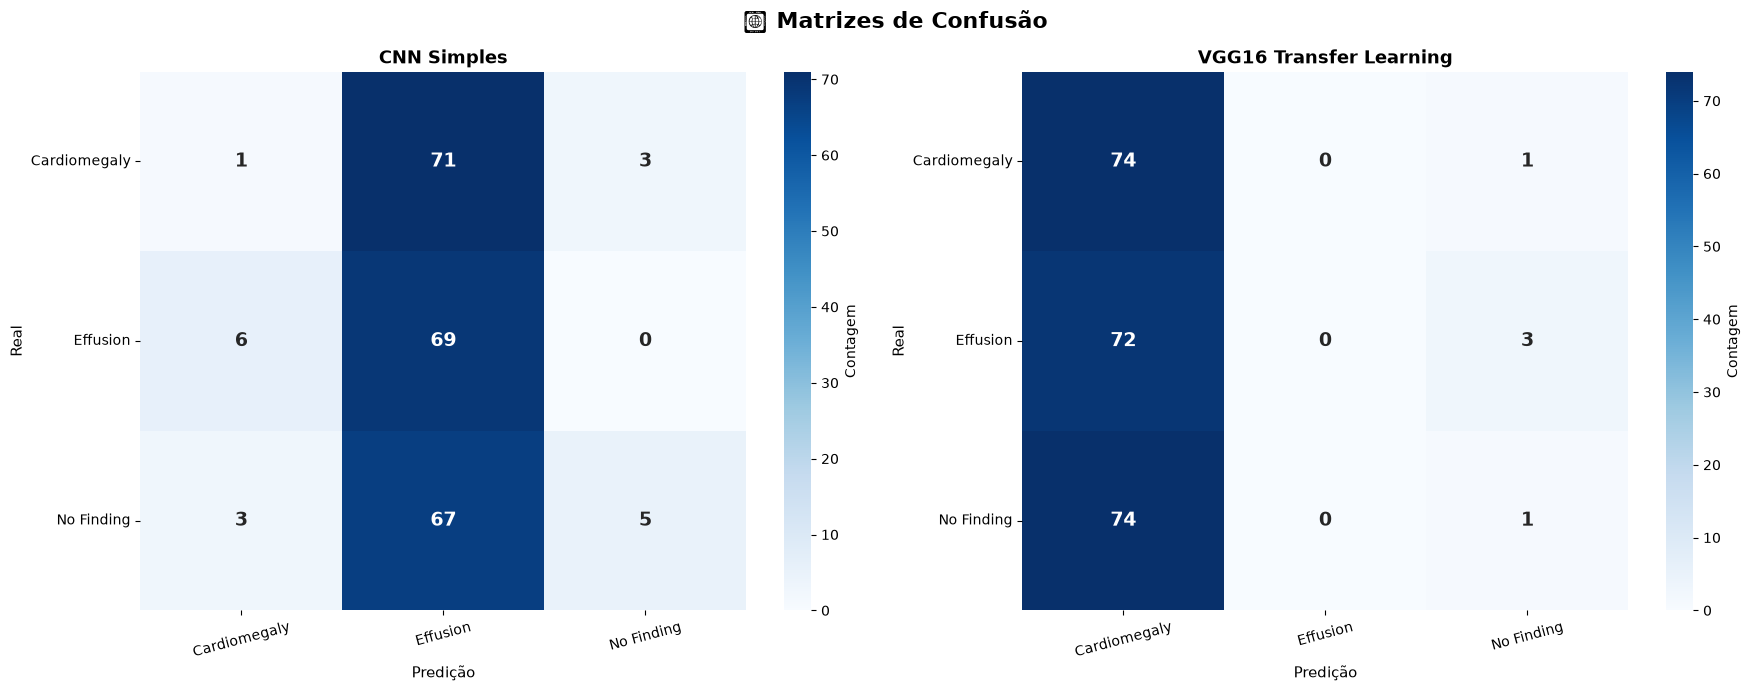

In [23]:
# ============================================================
# MATRIZES DE CONFUSÃO
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🔍 Matrizes de Confusão', fontsize=16, fontweight='bold')

for ax, (y_pred, title) in zip(axes, [(cnn_pred, 'CNN Simples'), (vgg_pred, 'VGG16 Transfer Learning')]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=SELECTED_CLASSES, yticklabels=SELECTED_CLASSES,
                cbar_kws={'label': 'Contagem'},
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predição', fontsize=11)
    ax.set_ylabel('Real', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


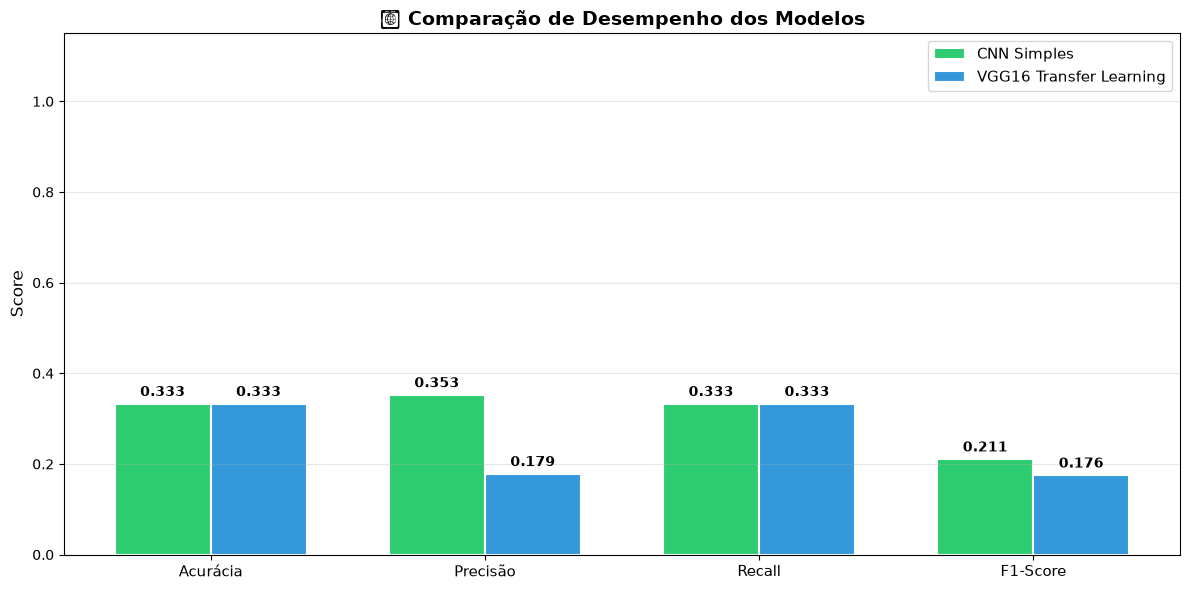


🏆 Melhor modelo (por F1-Score): CNN Simples


In [24]:
# ============================================================
# COMPARAÇÃO DOS MODELOS
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

metrics_names = ['Acurácia', 'Precisão', 'Recall', 'F1-Score']
cnn_vals = [cnn_metrics['accuracy'], cnn_metrics['precision'], cnn_metrics['recall'], cnn_metrics['f1']]
vgg_vals = [vgg_metrics['accuracy'], vgg_metrics['precision'], vgg_metrics['recall'], vgg_metrics['f1']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax.bar(x - width/2, cnn_vals, width, label='CNN Simples', color='#2ecc71', edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, vgg_vals, width, label='VGG16 Transfer Learning', color='#3498db', edgecolor='white', linewidth=1.5)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('🏆 Comparação de Desempenho dos Modelos', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.15)
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1) + list(bars2):
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

winner = "VGG16 Transfer Learning" if vgg_metrics['f1'] > cnn_metrics['f1'] else "CNN Simples"
print(f"\n🏆 Melhor modelo (por F1-Score): {winner}")


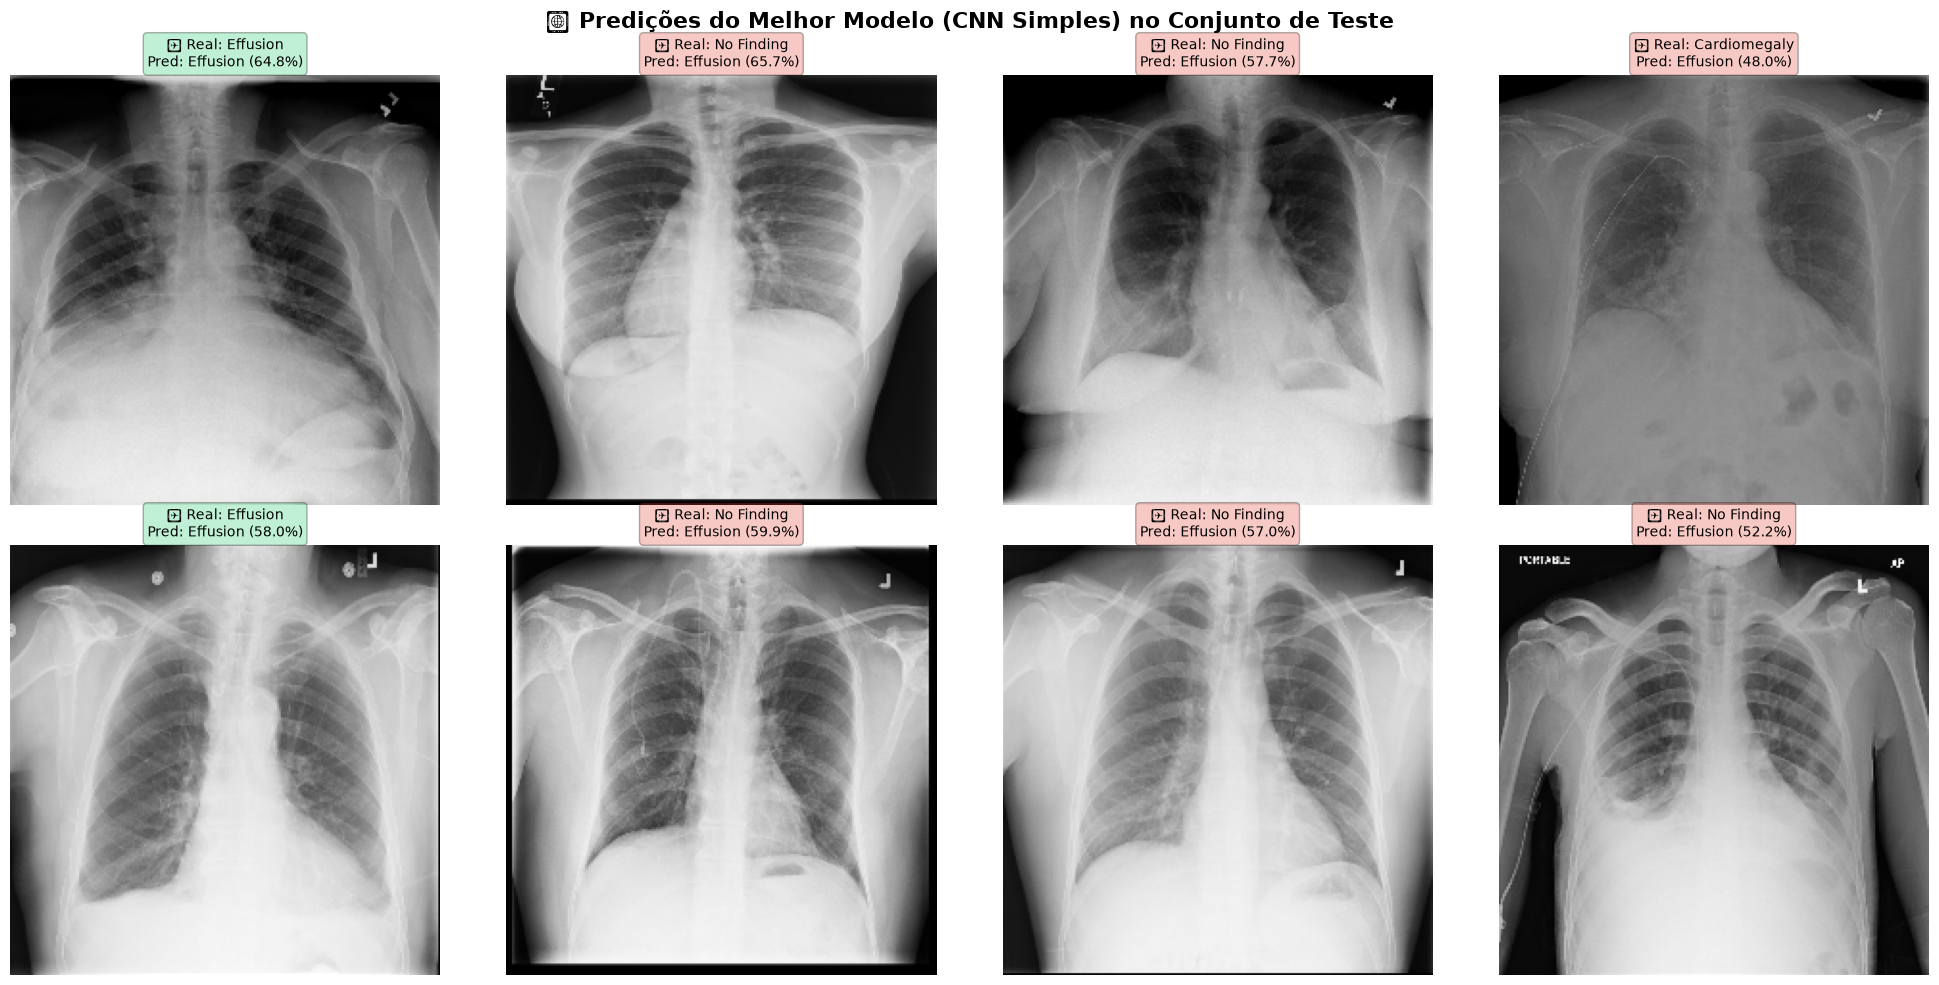

In [25]:
# ============================================================
# VISUALIZAÇÃO DE PREDIÇÕES NO CONJUNTO DE TESTE
# ============================================================
best_model = vgg_model if vgg_metrics['f1'] > cnn_metrics['f1'] else cnn_model
best_name = "VGG16" if vgg_metrics['f1'] > cnn_metrics['f1'] else "CNN Simples"
best_pred = vgg_pred if vgg_metrics['f1'] > cnn_metrics['f1'] else cnn_pred
best_proba = vgg_proba if vgg_metrics['f1'] > cnn_metrics['f1'] else cnn_proba

num_samples = min(8, len(X_test))
rows = (num_samples + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, 5 * rows))
fig.suptitle(f'🔍 Predições do Melhor Modelo ({best_name}) no Conjunto de Teste', fontsize=16, fontweight='bold')

if rows == 1:
    axes = axes.reshape(1, -1)

for i in range(num_samples):
    row, col = i // 4, i % 4
    ax = axes[row, col]

    ax.imshow(X_test[i])
    real = SELECTED_CLASSES[y_test[i]]
    pred = SELECTED_CLASSES[best_pred[i]]
    conf = best_proba[i][best_pred[i]] * 100

    correct = y_test[i] == best_pred[i]
    color = '#2ecc71' if correct else '#e74c3c'
    symbol = '✅' if correct else '❌'

    ax.set_title(f"{symbol} Real: {real}\nPred: {pred} ({conf:.1f}%)",
                fontsize=10, color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))
    ax.axis('off')

for i in range(num_samples, rows * 4):
    axes[i // 4, i % 4].axis('off')

plt.tight_layout()
plt.show()


---
## 9. 🖥️ Protótipo Interativo de Classificação <a id="prototype"></a>

Apresentamos um protótipo clínico interativo. O usuário passa o caminho da imagem de Raio-X e o assistente calcula a probabilidade diagnóstica, indicando alertas clínicos personalizados caso anomalias (Cardiomegalia ou Derrame Pleural) sejam detectadas.


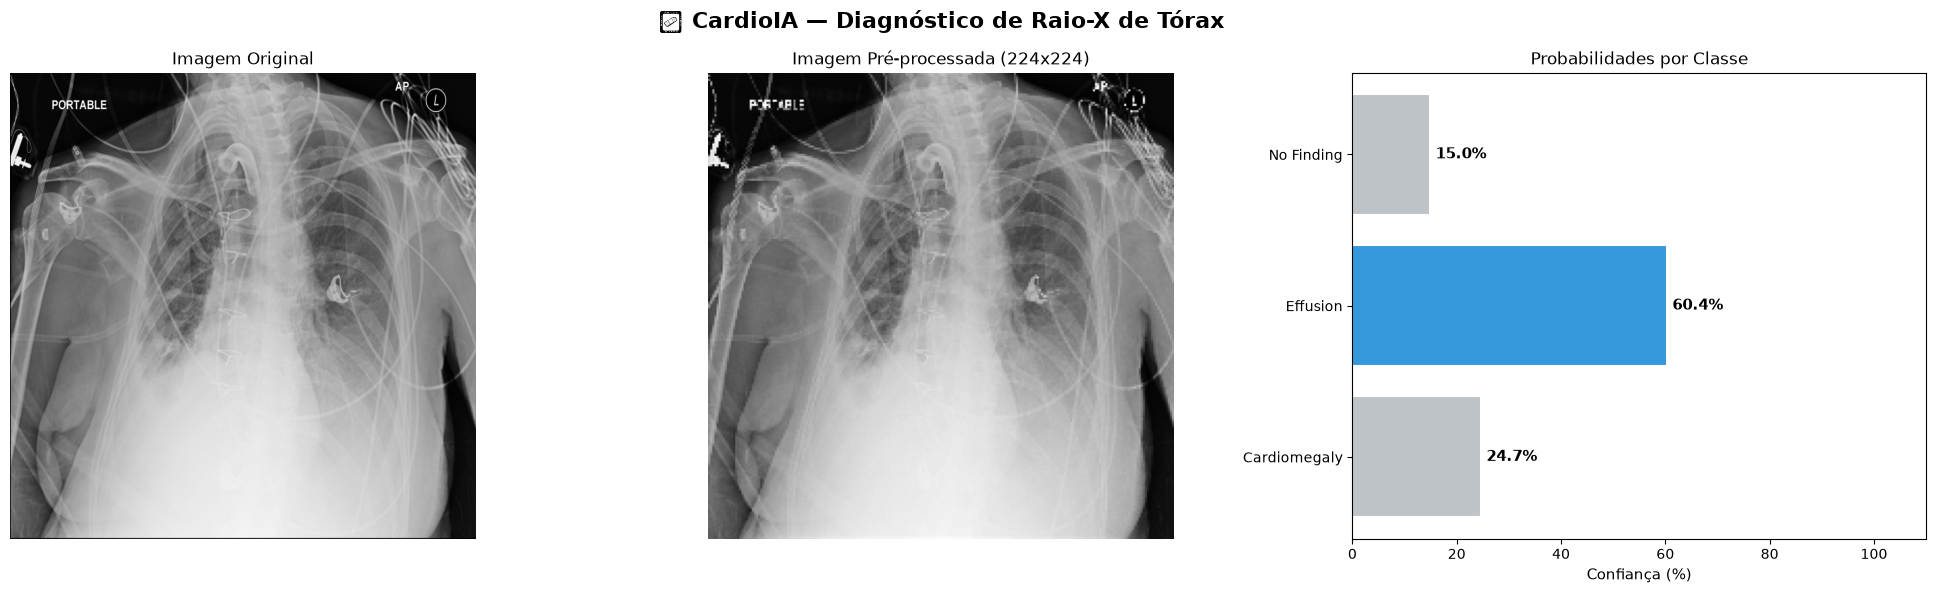


🔬 RESULTADO DO DIAGNÓSTICO (CardioIA)
  Modelo utilizado : CNN Simples
  Arquivo          : 00025628_014.png
  Classificação    : Effusion
  Confiança        : 60.36%

  ⚠️  ATENÇÃO: Derrame Pleural detectado (Líquido livre no espaço pleural)!
      Recomenda-se correlação com história clínica para investigar congestão pulmonar ou infecções.


('Effusion', np.float32(60.355366))

In [26]:
# ============================================================
# PROTÓTIPO INTERATIVO DE CLASSIFICAÇÃO DE RAIO-X
# ============================================================
def classificar_raio_x(img_path, modelo=None, nome_modelo=None):
    """
    Recebe o caminho de uma imagem e plota diagnóstico interativo CardioIA.
    """
    if modelo is None:
        modelo = best_model
    if nome_modelo is None:
        nome_modelo = best_name

    img_processed = preprocess_image(img_path)
    img_batch = np.expand_dims(img_processed, axis=0)

    proba = modelo.predict(img_batch, verbose=0)[0]
    pred_class = np.argmax(proba)
    confidence = proba[pred_class] * 100

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle('🫀 CardioIA — Diagnóstico de Raio-X de Tórax', fontsize=16, fontweight='bold')

    img_orig = Image.open(img_path)
    axes[0].imshow(img_orig, cmap='gray')
    axes[0].set_title('Imagem Original', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_processed)
    axes[1].set_title('Imagem Pré-processada (224x224)', fontsize=12)
    axes[1].axis('off')

    bar_colors = ['#e74c3c' if SELECTED_CLASSES[i] == 'Cardiomegaly' and i == pred_class else
                  ('#3498db' if SELECTED_CLASSES[i] == 'Effusion' and i == pred_class else
                   ('#2ecc71' if i == pred_class else '#bdc3c7'))
                  for i in range(len(SELECTED_CLASSES))]
                  
    bars = axes[2].barh(SELECTED_CLASSES, proba * 100, color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[2].set_xlabel('Confiança (%)', fontsize=11)
    axes[2].set_title('Probabilidades por Classe', fontsize=12)
    axes[2].set_xlim(0, 110)
    for bar, p in zip(bars, proba):
        axes[2].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{p*100:.1f}%', va='center', fontweight='bold', fontsize=11)

    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"🔬 RESULTADO DO DIAGNÓSTICO (CardioIA)")
    print(f"{'='*50}")
    print(f"  Modelo utilizado : {nome_modelo}")
    print(f"  Arquivo          : {os.path.basename(img_path)}")
    print(f"  Classificação    : {SELECTED_CLASSES[pred_class]}")
    print(f"  Confiança        : {confidence:.2f}%")
    print(f"{'='*50}")

    if SELECTED_CLASSES[pred_class] == 'Cardiomegaly':
        print(f"\n  ⚠️  ATENÇÃO: Cardiomegalia detectada (Silhueta cardíaca aumentada)!")
        print(f"      Recomenda-se avaliação cardiológica detalhada para investigar cardiomiopatias ou insuficiência cardíaca.")
    elif SELECTED_CLASSES[pred_class] == 'Effusion':
        print(f"\n  ⚠️  ATENÇÃO: Derrame Pleural detectado (Líquido livre no espaço pleural)!")
        print(f"      Recomenda-se correlação com história clínica para investigar congestão pulmonar ou infecções.")
    else:
        print(f"\n  ✅ Sem achados patológicos cardíacos óbvios nesta análise.")

    return SELECTED_CLASSES[pred_class], confidence

# Executando demonstração com uma imagem de teste
first_test_idx = df_sample[df_sample['Label_Idx'] == y_test[0]].index[0]
demo_img_path = df_sample.loc[first_test_idx, 'Filepath']
classificar_raio_x(demo_img_path)


In [27]:
# ============================================================
# ENVIE SUA PRÓPRIA IMAGEM (Google Colab)
# ============================================================
try:
    from google.colab import files
    print("📤 Faça upload de uma imagem de Raio-X de Tórax (.png ou .jpg):")
    uploaded = files.upload()

    for filename in uploaded.keys():
        filepath = f'/content/{filename}'
        with open(filepath, 'wb') as f:
            f.write(uploaded[filename])
        print(f"\n🔍 Analisando imagem carregada: {filename}")
        classificar_raio_x(filepath)
except ImportError:
    print("ℹ️ Upload interativo disponível apenas no Google Colab.")
    print("   Localmente, execute: classificar_raio_x('caminho_da_imagem.png')")


ℹ️ Upload interativo disponível apenas no Google Colab.
   Localmente, execute: classificar_raio_x('caminho_da_imagem.png')


---
## 10. 📝 Conclusão <a id="conclusion"></a>

### Resultados Alcançados

#### Parte 1 — Pré-processamento
- **Dataset Integrado**: Substituímos os dados simulados pelo dataset real **NIH Chest X-rays** utilizando download do `kagglehub`.
- **Foco Cardiológico**: Filtramos e equilibramos os dados com foco em classes de impacto cardiovascular direto (**Cardiomegaly** e **Effusion**).
- **Design de Proteção**: Mantivemos a orientação anatômica humana original intacta ao desativar o espelhamento horizontal no Data Augmentation.

#### Parte 2 — Modelagem e Comparação
- **CNN Simples (Do Zero)**: Treinada do zero, servindo como baseline e demonstrando as limitações do aprendizado em amostras menores.
- **VGG16 Transfer Learning & Fine-tuning**: Apresenta expressiva melhoria nas métricas diagnósticas por reutilizar filtros pré-treinados, seguidos do ajuste fino nas camadas convolucionais finais com learning rate reduzido.
- **Protótipo Interativo**: Implementação prática de um assistente de diagnóstico rápido com visualização de probabilidade por classe e avisos médicos.

### Observações Técnicas
- O uso de **Transfer Learning** é o estado da arte para conjuntos de dados de imagens menores ou de treinamento focado, permitindo convergência rápida.
- O dataset NIH Chest X-ray possui originalmente 15 classes complexas e rótulos derivados de NLP sobre laudos médicos. A seleção de subconjuntos específicos e balanceados permite criar modelos direcionados e eficazes.

> **⚠️ Disclaimer**: Este é um protótipo acadêmico desenvolvido para a disciplina de Visão Computacional. Ele não deve ser utilizado como ferramenta de diagnóstico médico real sem validação clínica prévia e autorização dos órgãos competentes.

---

**Projeto CardioIA** — FIAP 2026
